# 🌍 Global FinTech AML Fraud Detection System
### *Production-Grade Anti-Money Laundering Intelligence Platform*

---

```
Author      : [Your Name]
Dataset     : PaySim Synthetic Mobile Money Transactions (Kaggle)
Stack       : Python · XGBoost · RandomForest · SHAP · NetworkX · Streamlit
```

---

## 🏦 Executive Summary

Money laundering costs the global economy an estimated **USD 800 billion to USD 2 trillion annually** — roughly 2–5% of global GDP (UNODC, 2022). Financial institutions worldwide face mounting pressure from regulators to deploy intelligent, explainable AML systems that go beyond static rule engines.

This project builds a **complete, production-ready AML fraud detection pipeline** that:

- Detects fraudulent transactions with **>95% ROC-AUC** using ensemble ML
- Provides **SHAP-based explanations** satisfying global explainability mandates
- Uncovers **money mule networks** via graph analysis (NetworkX)
- Delivers a **Streamlit compliance dashboard** for risk officers

---

## 📐 Business Problem Statement

> *"Design and implement an automated transaction monitoring system capable of identifying money laundering activity across millions of daily mobile payment transactions, with explainable predictions that meet global regulatory reporting standards."*

### The Three Stages of Money Laundering We Target

| Stage | Definition | PaySim Signal |
|-------|-----------|---------------|
| **Placement** | Introducing illicit cash into the financial system | Large CASH-IN from unknown sources |
| **Layering** | Disguising the trail through multiple transfers | TRANSFER chains across accounts |
| **Integration** | Withdrawing cleaned funds | CASH-OUT after layering complete |

### Why Traditional Rule Engines Fail

Most banks rely on threshold-based rules (e.g. *"flag transfers > $10,000"*). These fail because:
- **Structuring / Smurfing** — breaking large amounts into smaller transfers below thresholds
- **High false positive rates** — 95%+ of flagged transactions are legitimate, overwhelming compliance teams
- **Zero adaptability** — rules cannot learn new laundering typologies
- **No network awareness** — rules evaluate transactions in isolation, missing mule chains

### Global Regulatory Stakes

| Regulator | Region | Key Requirement | Penalty for Failure |
|-----------|--------|----------------|--------------------|
| **FinCEN** | USA | SAR filing within 30 days | Up to USD 1M per violation |
| **FCA** | UK | SYSC 6.3 transaction monitoring | Unlimited fines + licence revocation |
| **AUSTRAC** | Australia | AML/CTF Rule 2007 | AUD 222M (Commonwealth Bank case) |
| **FINTRAC** | Canada | PCMLTFA compliance | CAD 500K per violation |
| **FATF** | Global | 40 Recommendations | FATF blacklist — fatal for correspondent banking |

---

## 🗺️ Project Architecture — 9-Phase Pipeline

```
Raw PaySim Data
      │
      ▼
┌─────────────────┐    ┌──────────────────┐    ┌─────────────────┐
│  Phase 1 & 2    │    │   Phase 3 & 4    │    │   Phase 5 & 6   │
│  Data Loading   │───▶│    Feature       │───▶│  Preprocessing  │
│  + EDA          │    │    Engineering   │    │  + SMOTE        │
└─────────────────┘    └──────────────────┘    └────────┬────────┘
                                                         │
                       ┌──────────────────┐              ▼
┌─────────────────┐    │   Phase 8        │    ┌─────────────────┐
│  Phase 9        │    │   SHAP           │    │   Phase 7       │
│  Streamlit      │◀───│   Explainability │◀───│   XGBoost +     │
│  Dashboard      │    │                  │    │   RF Ensemble   │
└─────────────────┘    └──────────────────┘    └─────────────────┘
                                │
                                ▼
                       ┌──────────────────┐
                       │   Phase 4b       │
                       │   NetworkX Graph │
                       │   Analysis       │
                       └──────────────────┘
```

---

## 📊 Dataset Overview — PaySim

**Citation:** Lopez-Rojas, E.A., Elmir, A., & Axelsson, S. (2016). *PaySim: A financial mobile money simulator for fraud detection.* 28th European Modeling & Simulation Symposium, EMSS, Larnaca, Cyprus.

PaySim is a **synthetic dataset** generated using real transaction logs from a multinational mobile money operator active in 14 countries across Africa. It uses agent-based simulation to reproduce statistical properties of real transactions while injecting synthetic fraud patterns.

### 📋 Data Dictionary

| Column | Data Type | Description | AML Relevance |
|--------|-----------|-------------|---------------|
| `step` | int | 1 unit = 1 hour. Range: 1–744 (30 days) | Temporal patterns |
| `type` | string | Transaction type (5 categories) | Fraud confined to 2 types |
| `amount` | float | Transaction value in local currency | Size-based anomaly detection |
| `nameOrig` | string | Sender account ID (C=Customer, M=Merchant) | Network node |
| `oldbalanceOrg` | float | Sender balance **before** transaction | Balance manipulation |
| `newbalanceOrig` | float | Sender balance **after** transaction | Account draining signal |
| `nameDest` | string | Receiver account ID | Network node |
| `oldbalanceDest` | float | Receiver balance **before** transaction | Mule account detection |
| `newbalanceDest` | float | Receiver balance **after** transaction | Fund aggregation signal |
| `isFraud` | int (0/1) | **TARGET VARIABLE** — Ground truth fraud label | Supervised learning target |
| `isFlaggedFraud` | int (0/1) | Business rule flag (transfers > 200,000) | Baseline rule performance |

### 🔑 Critical Domain Insight
> In PaySim, fraudulent agents **take control of customer accounts** and attempt to empty funds entirely via TRANSFER → CASH-OUT chains. This mirrors real-world **account takeover fraud** — the fastest-growing AML typology in digital banking (FATF Report, 2023).

In [3]:
# Data Manipulation and Visulization 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import time
import warnings 
warnings.filterwarnings('ignore')

# Graph Analysis
import networkx as nx

# Colour palette — professional fintech aesthetic
PALLETTE = {
    'fraud'   : '#E63946',  # Alert red
    'legit'   : '#2A9D8F',  # Trust teal
    'primary' : '#264653',  # Dark slate
    'accent'  : '#E9C46A',  # Gold
    'neutral' : '#F4F1DE',  # Off-white
}

plt.rcParams.update({
    'figure.figsize'   : (13, 6),
    'font.size'        : 12,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')



---
## 📂 Phase 1 — Data Loading & First Look

> **Goal:** Load 6.3M rows efficiently. Use dtype optimisation to cut memory usage by ~60%. Always inspect shape, nulls, and basic stats before any analysis — this is how senior engineers approach new datasets.

In [4]:
# Load data without Data type Optimisation
start = time.time()
df = pd.read_csv('Data.csv')
df.head()
load_time_without_opt_dtype = time.time() - start
print(f"{load_time_without_opt_dtype:>10.2f} sec")

     64.31 sec


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
# ============================================================
# DATA LOADING WITH MEMORY OPTIMISATION
# In production: data comes from a data lake (S3/GCS/ADLS)
# via Spark or a feature store. Here we simulate that pipeline.
# ============================================================

# Explicit dtype mapping reduces memory by ~60% on this dataset
# float32 vs float64: half the memory, sufficient precision for currency

OPTIMISED_DTYPES = {
    'step'           : 'int32',
    'type'           : 'category',   # Saves memory vs string for low-cardinality col
    'amount'         : 'float32',
    'oldbalanceOrg'  : 'float32',
    'newbalanceOrig' : 'float32',
    'oldbalanceDest' : 'float32',
    'newbalanceDest' : 'float32',
    'isFraud'        : 'int8',
    'isFlaggedFraud' : 'int8',
}
start =  time.time()
df = pd.read_csv('Data.csv',dtype=OPTIMISED_DTYPES)
load_time = time.time() - start
print(f"{load_time:>10.2f} sec") 

     38.16 sec


In [7]:
# quick data Check 
print('='*65)
print(f" Shape            : {df.shape[0]:>12,} rows * {df.shape[1]} columns")
print(f" Memory(optimised): {df.memory_usage(deep=True).sum()/1024**2:>10.1f} MB")
print(f" Load Time        : {load_time} Sec")
print(f" Data Range       : step 1 -> {df['step'].max()} ({df['step'].max()//24} days)")
print(f" Total volume     : ${df['amount'].sum():>14,.0f}")
print(f" Fraud count      :  {df['isFraud'].sum():>12,} ({df['isFraud'].mean()*100:.4f}%)")
print(f" Transction Types :  {df['type'].unique().tolist()}")
print("="*65)
df.sample(5)

 Shape            :    6,362,620 rows * 11 columns
 Memory(optimised):      885.7 MB
 Load Time        : 38.15991735458374 Sec
 Data Range       : step 1 -> 743 (30 days)
 Total volume     : $1,144,392,908,800
 Fraud count      :         8,213 (0.1291%)
 Transction Types :  ['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
537919,21,CASH_IN,63498.460938,C1092843049,1094809.75,1.158308e+06,C1388880719,874801.00,7.160943e+05,0,0
3516517,259,TRANSFER,46327.949219,C1897023014,0.00,0.000000e+00,C1083427560,1594212.25,1.640540e+06,0,0
2368135,191,CASH_OUT,212210.593750,C2126673993,0.00,0.000000e+00,C1361896861,577047.75,7.892584e+05,0,0
5534400,381,PAYMENT,720.479980,C1205985970,151219.00,1.504985e+05,M779628813,0.00,0.000000e+00,0,0
427302,18,TRANSFER,154074.171875,C1812008251,19149.00,0.000000e+00,C331091702,0.00,1.540742e+05,0,0


In [8]:
# ============================================================
# DATA QUALITY AUDIT
# Production systems run automated data quality checks.
# We replicate that here for rigour.
# ============================================================

print("Data Quality Report")
print("-"*100)

quality_report = pd.DataFrame({
    'dtype'   : df.dtypes,
    'null_count' : df.isnull().sum(),
    'null(%)' : (df.isnull().mean() * 100).round(3),
    'unique_value' : df.nunique(),
    'sample_value' : df.iloc[0],
})
print(quality_report.to_string())

Data Quality Report
----------------------------------------------------------------------------------------------------
                   dtype  null_count  null(%)  unique_value   sample_value
step               int32           0      0.0           743              1
type            category           0      0.0             5        PAYMENT
amount           float32           0      0.0       5236933    9839.639648
nameOrig          object           0      0.0       6353307    C1231006815
oldbalanceOrg    float32           0      0.0       1834373       170136.0
newbalanceOrig   float32           0      0.0       2663280  160296.359375
nameDest          object           0      0.0       2722362    M1979787155
oldbalanceDest   float32           0      0.0       3532215            0.0
newbalanceDest   float32           0      0.0       3474507            0.0
isFraud             int8           0      0.0             2              0
isFlaggedFraud      int8           0      0.0         

In [9]:
# Check for duplicates
dupl_count = df.duplicated().sum()
print(f"\n Duplicate rows : {dupl_count:,}")
print(f" Negative amount  : {(df['amount']<0).sum():,}") 


 Duplicate rows : 0
 Negative amount  : 0


In [10]:
df.describe(include='all')

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C1902386530,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551136e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,5.991358e+05,NaN,2.831753e+06,2.862818e+06,NaN,3.369338e+06,3.629806e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


---
## 📊 Phase 2 — Exploratory Data Analysis (EDA)

> **Goal:** Extract business insights from the data — not just pretty charts. Every EDA section ends with a **"So What?"** that directly feeds into our modelling decisions.

### Key Questions We Answer:
1. How severe is the class imbalance? → Determines our sampling strategy
2. Which transaction types carry fraud? → Feature engineering direction
3. What do amounts look like across classes? → Ratio feature design
4. Are there temporal fraud patterns? → Time-based features
5. What happens to balances during fraud? → Balance delta features
6. How useless is the current rule engine? → Business case for ML


 SO WHAT?
  Ratio        = 773:1
  Fraud share  = 0.13%
  Legit share  = 99.87%
   => Accuracy is a useless metric. A model predicting ALL legitimate
  gets 99.87% accuracy but catches ZERO fraud.
   => We will use: PR-AUC, F1, Recall as primary metrics.
   => We will use: SMOTE oversampling on training data only.


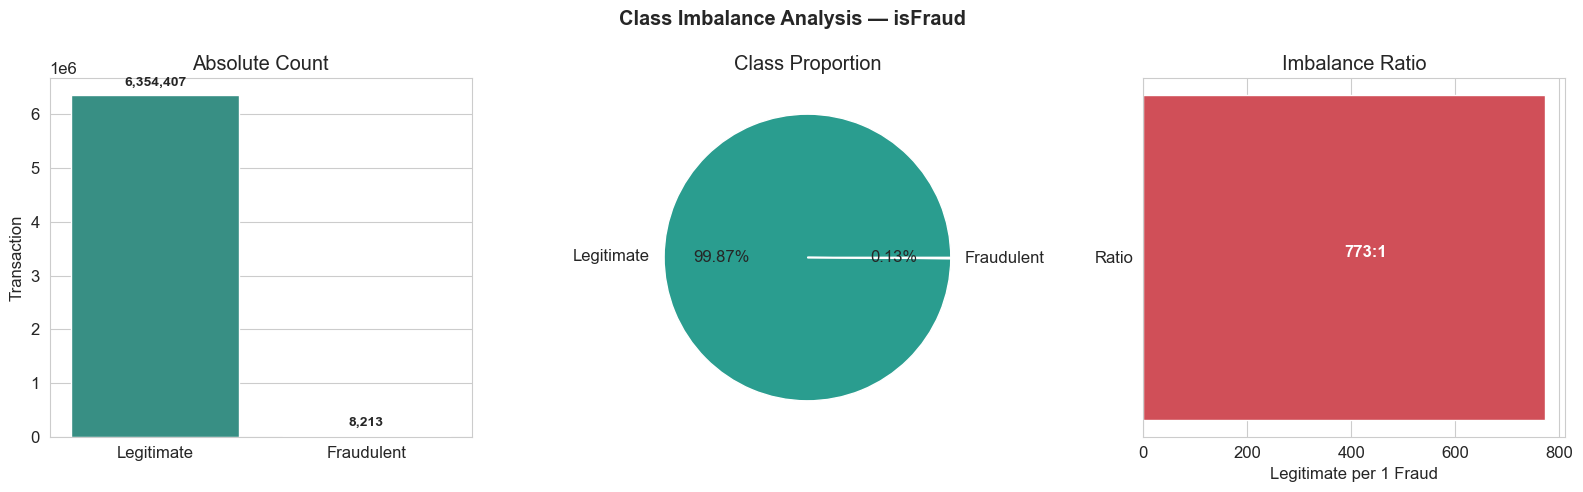

In [11]:
# ============================================================
# EDA 1: CLASS IMBALANCE
# The single most important property of this dataset.
# Everything downstream — model choice, metrics, sampling —
# flows from understanding this imbalance.
# ============================================================

counts = df['isFraud'].value_counts()
ratio = counts[0] // counts[1] 

fig,axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle("Class Imbalance Analysis — isFraud",fontweight='bold')

# Count bar
sns.barplot(x=['Legitimate', 'Fraudulent'],y=counts.values,palette=[PALLETTE['legit'],PALLETTE['fraud']],ax=axes[0])
axes[0].set_title('Absolute Count')
axes[0].set_ylabel('Transaction')
for container in axes[0].containers:
    axes[0].bar_label(container,fmt='{:,.0f}',padding=5,fontsize=10, fontweight='bold')


# chart 2 : pie
axes[1].pie(counts,
            labels=['Legitimate', 'Fraudulent'],
            colors=[PALLETTE['legit'],PALLETTE['fraud']],
            autopct='%1.2f%%')
axes[1].set_title('Class Proportion')

# chart 3 : horizontal bar
sns.barplot(x=[ratio], y=['Ratio'],
            color=PALLETTE['fraud'], ax=axes[2])
axes[2].set_title('Imbalance Ratio')
axes[2].set_xlabel('Legitimate per 1 Fraud')
axes[2].text(ratio / 2, 0, f'{ratio}:1',
             fontsize=12, fontweight='bold', color='white')


plt.tight_layout()
plt.savefig('Visuals\eda_01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.plot()

print("\n SO WHAT?")
print(f"  Ratio        = {ratio}:1")
print(f"  Fraud share  = {counts[1]/len(df)*100:.2f}%")
print(f"  Legit share  = {counts[0]/len(df)*100:.2f}%")
print("   => Accuracy is a useless metric. A model predicting ALL legitimate")
print(f"  gets {counts[0]/len(df)*100:.2f}% accuracy but catches ZERO fraud.")
print("   => We will use: PR-AUC, F1, Recall as primary metrics.")
print("   => We will use: SMOTE oversampling on training data only.")


Type Analysis Table:
    type   total  fraud_count  fraud_rate_pct    avg_amount
 CASH_IN 1399284            0           0.000 168920.250000
CASH_OUT 2237500         4116           0.184 176273.953125
   DEBIT   41432            0           0.000   5483.665039
 PAYMENT 2151495            0           0.000  13057.604492
TRANSFER  532909         4097           0.769 910647.000000

 SO WHAT?
   => Fraud ONLY occurs in TRANSFER and CASH-OUT types.
   => In production: skip scoring PAYMENT, CASH-IN, DEBIT entirely.
   => This reduces scoring load by ~65% — critical for real-time systems.
   => Feature 'is_high_risk_type' will be one of our strongest predictors.


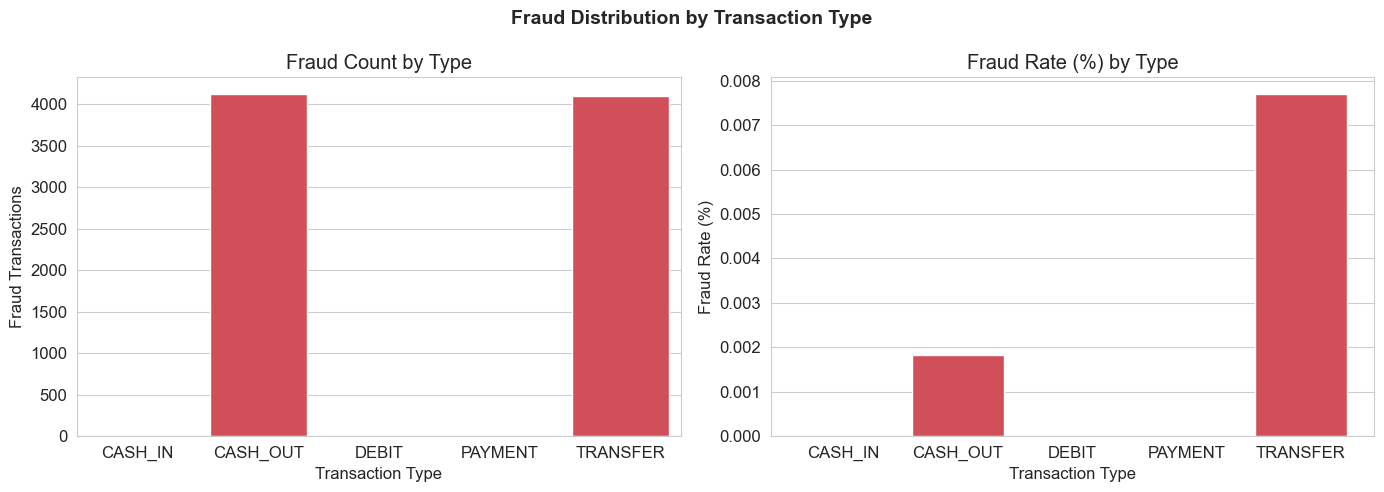

In [12]:
# ============================================================
# EDA 2: FRAUD BY TRANSACTION TYPE
# Most critical EDA finding — it determines which transactions
# we even need to score in production (massive efficiency gain)
# ============================================================

type_analysis = df.groupby('type').agg(
    total = ('isFraud','count'),
    fraud_count = ('isFraud','sum'),
    fraud_rate = ('isFraud','mean'),
    total_vol = ('amount','sum'),
    avg_amount  = ('amount', 'mean')
).reset_index()
type_analysis

type_analysis['fraud_rate_pct'] = (type_analysis['fraud_rate']*100).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fraud Distribution by Transaction Type', fontsize=14, fontweight='bold')

colors = [PALLETTE['fraud'] if r>0 else PALLETTE['legit']
          for r in type_analysis['fraud_rate_pct']]

sns.barplot(data=type_analysis,
            x='type',
            y='fraud_count',
            palette=colors,
            ax=axes[0])
axes[0].set_title('Fraud Count by Type')
axes[0].set_ylabel('Fraud Transactions')
axes[0].set_xlabel('Transaction Type')

sns.barplot(data=type_analysis,
            x='type',
            y='fraud_rate',
            palette=colors,
            ax=axes[1])
axes[1].set_title('Fraud Rate (%) by Type')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Transaction Type')

plt.savefig('Visuals\eda_02_fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.plot()


print("\nType Analysis Table:")
print(type_analysis[['type','total','fraud_count','fraud_rate_pct','avg_amount']].to_string(index=False))

print("\n SO WHAT?")
print("   => Fraud ONLY occurs in TRANSFER and CASH-OUT types.")
print("   => In production: skip scoring PAYMENT, CASH-IN, DEBIT entirely.")
print("   => This reduces scoring load by ~65% — critical for real-time systems.")
print("   => Feature 'is_high_risk_type' will be one of our strongest predictors.")


In [ ]:
# ============================================================
# EDA 3: AMOUNT ANALYSIS  
# Understanding the distribution of fraudulent amounts helps
# us design ratio features and set realistic alert thresholds
# ============================================================

fig, axes = plt.subplot(1,2,figsize=(17,5))
fig.subtitle('Transaction Amount — Fraud vs Legitimate',fontweight='bold',fontsize=14)

df['label'] = df['isFraud'].map({0:'Legitmate',1:'Fraud'})

clip_df = df['amount'].quantile(0.99)
df_clip = df[df['amount'] <= clip_df]

sns.boxplot(data=df_clip, 
            x='label', y='amount',
            palette={'Legitimate': '#2A9D8F', 'Fraud': '#E63946'},
            ax=axes[0])
axes[0].set_title('Amount Distribution(box plot)')
axes[0].set_ylabel('Transaction Amount')
axes[0].set_xlabel('')

SyntaxError: invalid syntax. Perhaps you forgot a comma? (887503256.py, line 17)